In [24]:
pathout = ".."

import sys
sys.path.append(pathout)
from TheModel import *
import os

In [ ]:
################# Params to change ################
epsi=.005
C=15
alpha = 0.12
s=0.25
mmax=0
tmax=10*360
###################################################

p = {
        'y0':[1-epsi,0,0,epsi,0,0,0,0,0,0,0],
        'beta': C*alpha,
        'alpha': alpha,
        'gamma': .1,
        'nu': .01,
        'tmin': 0,
        'tmax': tmax,
        'stepsize': 0.1,      
        'maxstep': 10,
        'direction': True,
        's': s,              # seasonality amplitude
        'w': 2*np.pi/360,        # seasonality frequency (repeats after every 360days)
        'seasonalshift': 0,
        'mmax': mmax,
        'hthres': 2*1/1000,
        'epsilon_m': 2*0.00025, # =0.0005
        'tau': 36,
        'distinguishable': False,
        'tolerances': [1e-15,1e-18],
    }

###############################
InInfComp = 'A and B' ######### 'A and B' or 'AB' Doesnt change much because we start at alpha=0.12 away from the basin boarder. Need lower tolerances though
###############################

SetInCondfullSIRS(epsi, p, InInfComp)

def SetParams(p, alpha, kappa, C, epsi, s, mmax, tmax, cut_fraction):
    SetInCondfullSIRS(epsi, p, InInfComp)
    p['gamma'] = .1/kappa
    p['alpha'] = alpha/kappa
    p['nu'] = .01/kappa
    p['beta'] = C*alpha/kappa
    p['s'] = s
    p['mmax'] = mmax
    p['tmax'] = tmax
    cut = int(p['tmax']/p['stepsize']*cut_fraction)
    return cut



In [3]:
tmax = 10*360
timesteps = int(tmax/p['stepsize'])
DataToPlot = np.zeros((8, 2, timesteps)) # (modeltypes, plotting dimensions, timesteps)

# Comparison btw models:

```text
SIRS: EE          - alpha = .09, kappa=1,   C=15, epsi=.005, s=0,   mmax=0
SIRS: DFE         - alpha = .09, kappa=1,   C=5 , epsi=.005, s=0,   mmax=0
SIRSs: end. LC    - alpha = .09, kappa=.25, C=15, epsi=.005, s=.4,  mmax=0
SIRSs: DFE FP     - alpha = .09, kappa=.25, C=15, epsi=.005, s=.99, mmax=0
SIRSm: end. FP    - alpha = .12, kappa=.2,  C=15, epsi=.005, s=0,   mmax=.5
SIRSm: lowprev LC - alpha = .12, kappa=.2,  C=15, epsi=.005, s=0,   mmax=.6
SIRSsm: periodic  - alpha = .12, kappa=.2,  C=15, epsi=.005, s=.25, mmax=.6
SIRSsm: chaotic   - alpha = .12, kappa=.2,  C=25, epsi=.005, s=.25, mmax=.75
```

## SIRS: EE

In [4]:
alpha = 0.09
kappa=1
C=15
epsi=.005
s=0
mmax=0
tmax=10*360
cut_fraction=0

cut = SetParams(p, alpha, kappa, C, epsi, s, mmax, tmax, cut_fraction)

print('R0=', np.round(p['alpha']/p['gamma'],3))


R0= 0.9


c:\Users\PCUser\miniconda3\envs\MYENV\Lib\site-packages\scipy\integrate\_ivp\ivp.py:623: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


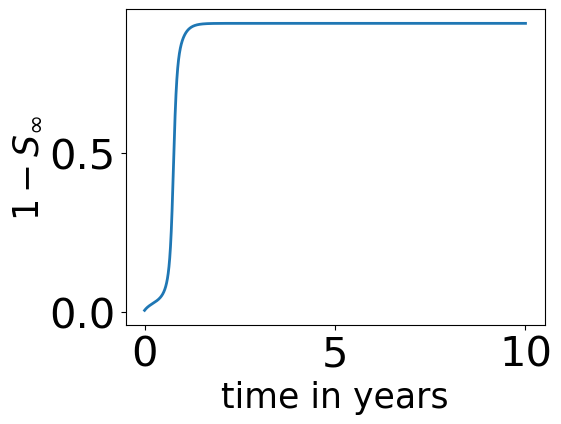

In [5]:
m = model(**p)
times, Data = m.run()
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
times = times[cut:]

DataToPlot[0] = [times, 1-S]

plt.plot(times/360, 1-S, lw=2)
        
plt.xlabel(r'time in years')
plt.ylabel(r'$1-S_\infty$')
plt.tight_layout()
#plt.savefig('img/SIRSsm_LimitCyclesInMitig+Seas_at_delta=0_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

## SIRS: DFE

In [ ]:
alpha = 0.09
kappa=1
C=5
epsi=.005
s=0
mmax=0
tmax=10*360
cut_fraction=0

cut = SetParams(p, alpha, kappa, C, epsi, s, mmax, tmax, cut_fraction)

print('R0=', np.round(p['alpha']/p['gamma'],3))


R0= 0.9


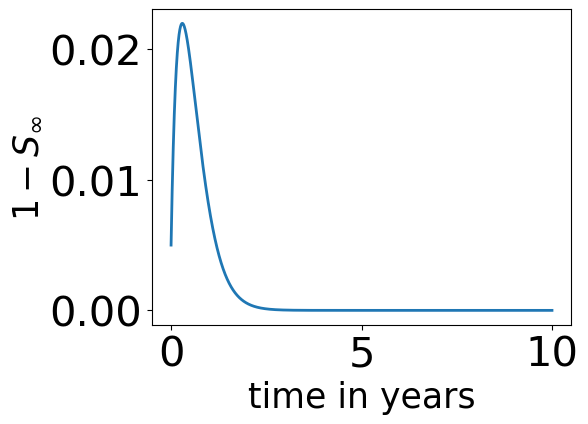

In [7]:
m = model(**p)
times, Data = m.run()
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
times = times[cut:]

DataToPlot[1] = [times, 1-S]

plt.plot(times/360, 1-S, lw=2)
        
plt.xlabel(r'time in years')
plt.ylabel(r'$1-S_\infty$')
plt.tight_layout()
#plt.savefig('img/SIRSsm_LimitCyclesInMitig+Seas_at_delta=0_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

## SIRSs: endemic LC

In [ ]:
alpha = 0.09
kappa=0.25
C=15
epsi=.005
s=0.4
mmax=0
tmax=10*360
cut_fraction=0

cut = SetParams(p, alpha, kappa, C, epsi, s, mmax, tmax, cut_fraction)

print('R0=', np.round(p['alpha']/p['gamma'],3))


R0= 0.9


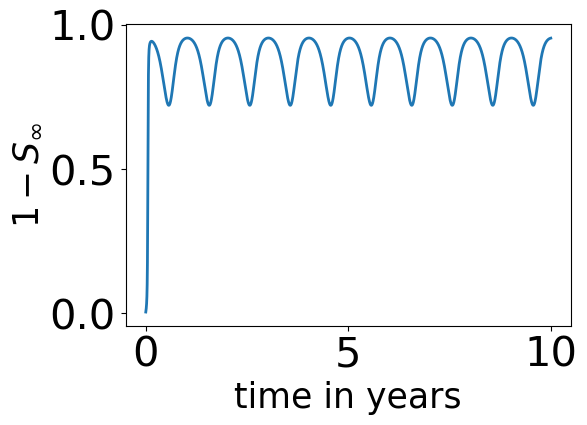

In [45]:
m = model(**p)
times, Data = m.run()
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
times = times[cut:]

DataToPlot[2] = [times, 1-S]

plt.plot(times/360, 1-S, lw=2)
        
plt.xlabel(r'time in years')
plt.ylabel(r'$1-S_\infty$')
plt.tight_layout()
#plt.savefig('img/SIRSsm_LimitCyclesInMitig+Seas_at_delta=0_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

## SIRSs: DFE FP

In [ ]:
alpha = 0.09
kappa=.25
C=15
epsi=.005
s=0.99
mmax=0
tmax=10*360
cut_fraction=0

cut = SetParams(p, alpha, kappa, C, epsi, s, mmax, tmax, cut_fraction)

print('R0=', np.round(p['alpha']/p['gamma'],3))


R0= 0.9


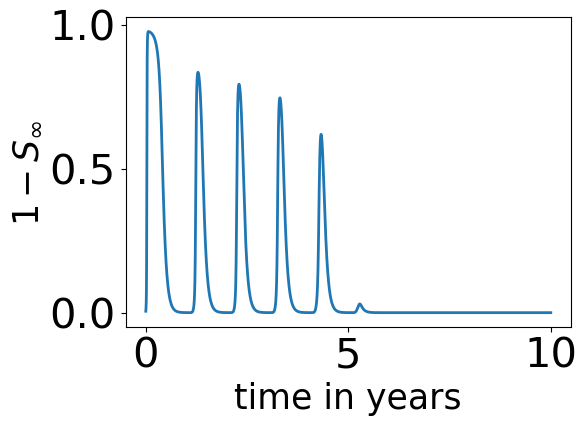

In [51]:
m = model(**p)
times, Data = m.run()
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
times = times[cut:]

DataToPlot[3] = [times, 1-S]

plt.plot(times/360, 1-S, lw=2)

plt.xlabel(r'time in years')
plt.ylabel(r'$1-S_\infty$')
plt.tight_layout()
plt.show()

## SIRSm: endemic FP

In [ ]:
alpha = 0.12
kappa=0.2
C=15
epsi=.005
s=0
mmax=0.5
tmax=10*360
cut_fraction=0

cut = SetParams(p, alpha, kappa, C, epsi, s, mmax, tmax, cut_fraction)

print('R0=', np.round(p['alpha']/p['gamma'],3))


R0= 1.2


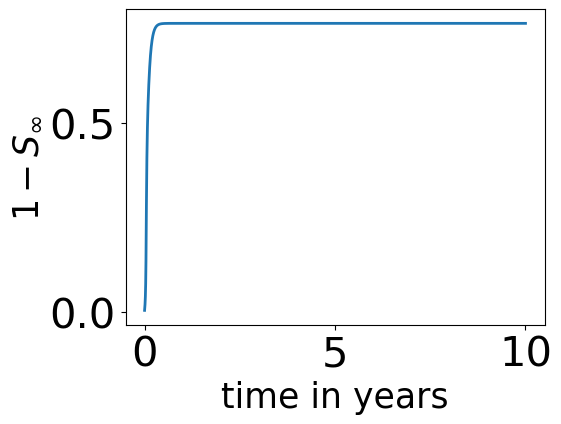

In [13]:
m = model(**p)
times, Data = m.run()
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
times = times[cut:]

DataToPlot[4] = [times, 1-S]

plt.plot(times/360, 1-S, lw=2)
        
plt.xlabel(r'time in years')
plt.ylabel(r'$1-S_\infty$')
plt.tight_layout()
#plt.savefig('img/SIRSsm_LimitCyclesInMitig+Seas_at_delta=0_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

## SIRSm: low-prevalence LC

In [ ]:
alpha = 0.12
kappa=0.2
C=15
epsi=.005
s=0
mmax=0.6
tmax=10*360
cut_fraction=0

cut = SetParams(p, alpha, kappa, C, epsi, s, mmax, tmax, cut_fraction)

print('R0=', np.round(p['alpha']/p['gamma'],3))


R0= 1.2


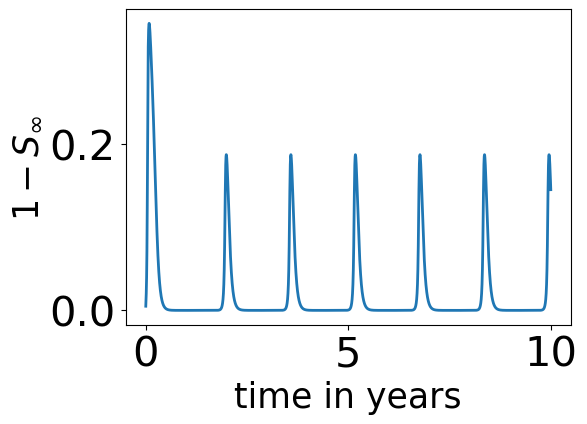

In [15]:
m = model(**p)
times, Data = m.run()
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
times = times[cut:]

DataToPlot[5] = [times, 1-S]

plt.plot(times/360, 1-S, lw=2)
        
plt.xlabel(r'time in years')
plt.ylabel(r'$1-S_\infty$')
plt.tight_layout()
#plt.savefig('img/SIRSsm_LimitCyclesInMitig+Seas_at_delta=0_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

## SIRSsm: complex periodic behavior

In [ ]:
alpha = 0.12
kappa=0.2
C=15
epsi=.005
s=0.25
mmax=0.6
tmax=10*360
cut_fraction=0

cut = SetParams(p, alpha, kappa, C, epsi, s, mmax, tmax, cut_fraction)

print('R0=', np.round(p['alpha']/p['gamma'],3))


R0= 1.2


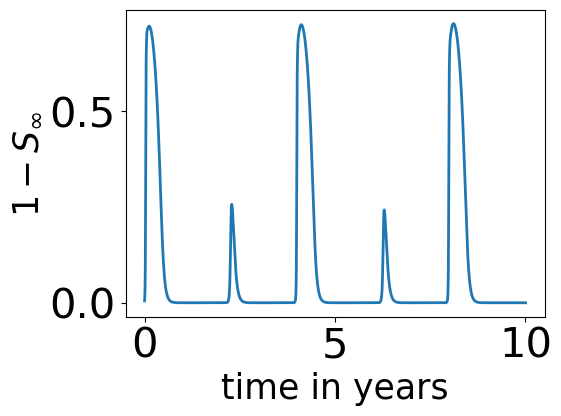

In [17]:
m = model(**p)
times, Data = m.run()
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
times = times[cut:]

DataToPlot[6] = [times, 1-S]

plt.plot(times/360, 1-S, lw=2)
        
plt.xlabel(r'time in years')
plt.ylabel(r'$1-S_\infty$')
plt.tight_layout()
#plt.savefig('img/SIRSsm_LimitCyclesInMitig+Seas_at_delta=0_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

## SIRSsm: chaotic behavior

In [ ]:
alpha = 0.12
kappa=0.2
C=25
epsi=.005
s=0.25
mmax=0.75
tmax=10*360
cut_fraction=0

cut = SetParams(p, alpha, kappa, C, epsi, s, mmax, tmax, cut_fraction)

print('R0=', np.round(p['alpha']/p['gamma'],3))


R0= 1.2


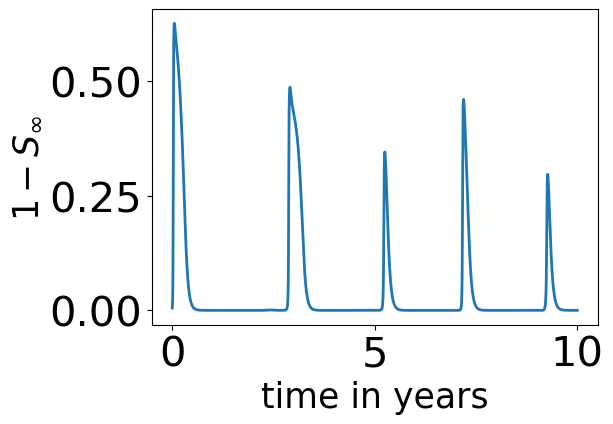

In [19]:
m = model(**p)
times, Data = m.run()
S,A,B,AB,Ab,aB,a,b,ab,H,H1 = Data[:,cut:]
times = times[cut:]

DataToPlot[7] = [times, 1-S]

plt.plot(times/360, 1-S, lw=2)
        
plt.xlabel(r'time in years')
plt.ylabel(r'$1-S_\infty$')
plt.tight_layout()
#plt.savefig('img/SIRSsm_LimitCyclesInMitig+Seas_at_delta=0_fordiff_RateFractions_mmax.pdf', bbox_inches='tight')
plt.show()

## Plot

C:\Users\PCUser\AppData\Local\Temp\ipykernel_12260\710094802.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


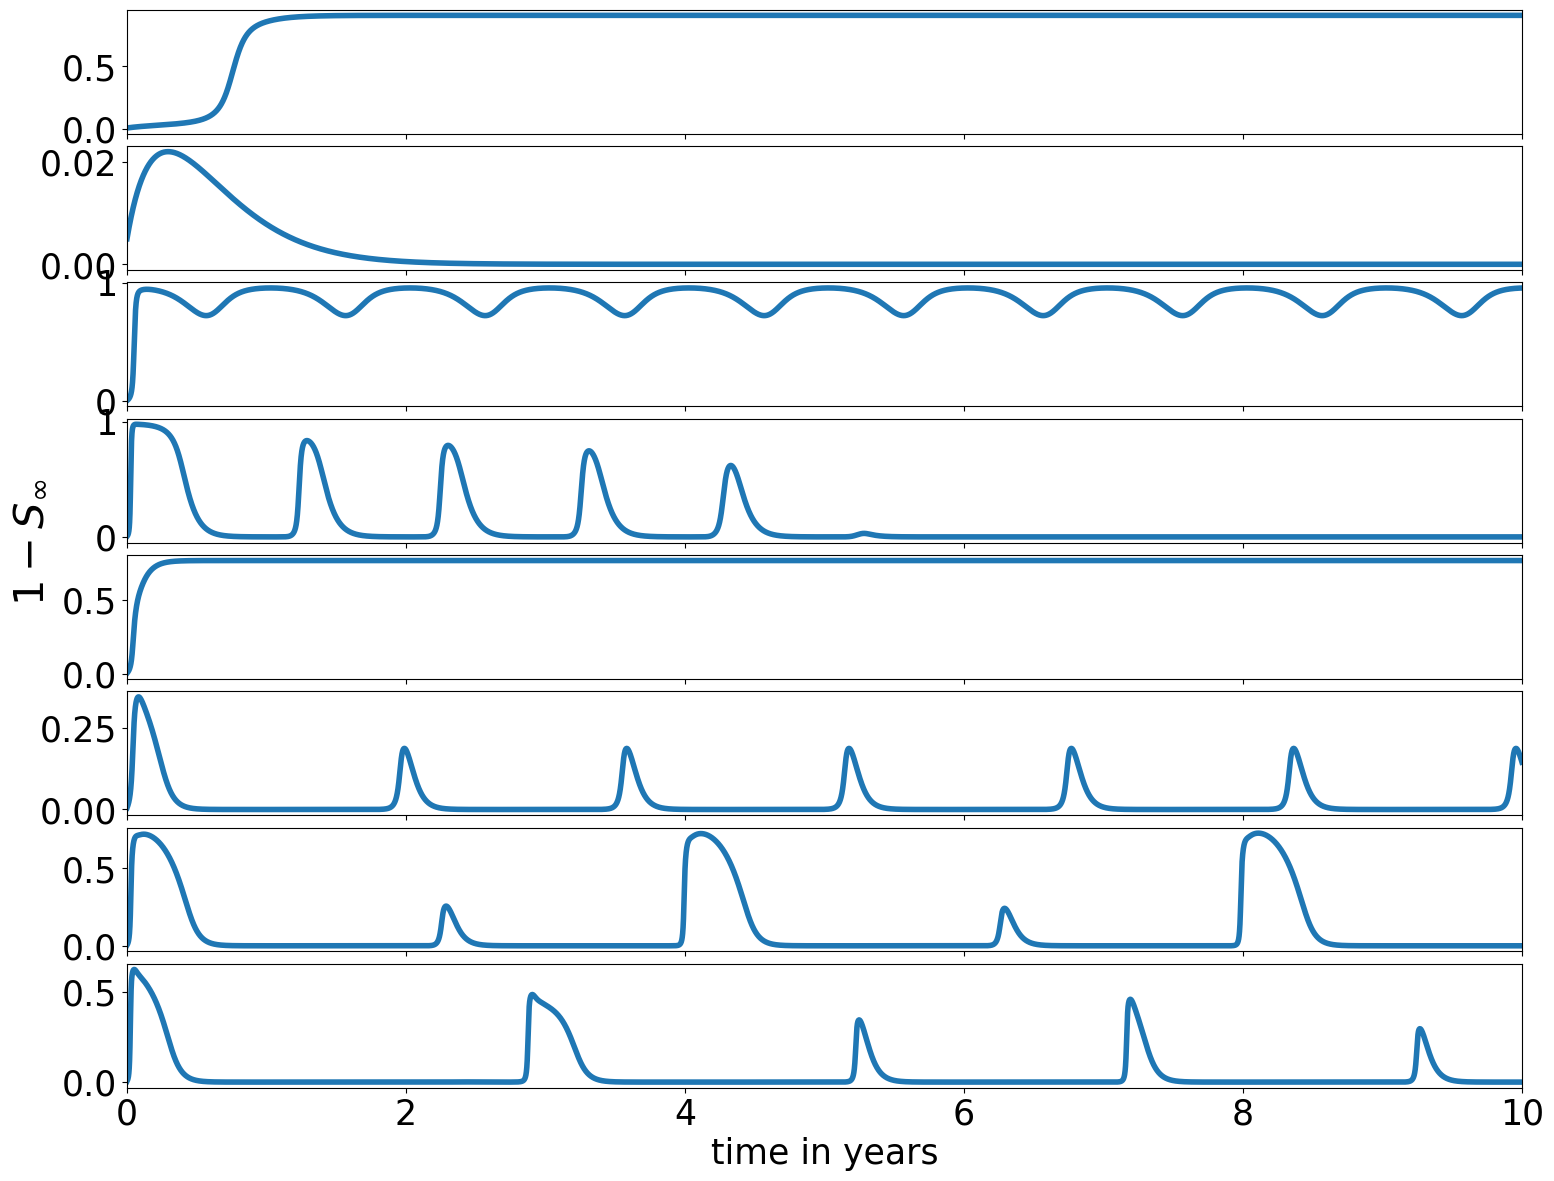

In [70]:
fig, axes = plt.subplots(8, 1, figsize=(18, 14), gridspec_kw={'hspace': 0.1})

plt.rcParams['font.size'] = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['axes.titlesize'] = 30

for i in range(8):
    axes[i].plot(DataToPlot[i][0]/360, DataToPlot[i][1], lw=4)

for i in range(8):
    axes[i].set_xlim(0, 10)
for i in range(7): 
    axes[i].tick_params(labelbottom=False)
axes[-1].set_xlabel(r'time in years')
fig.supylabel(r'$1-S_\infty$', x=0.06)

fig.tight_layout()
plt.savefig('img/SIRS(s)(m)_TimeevolComparison_forPaper.pdf', bbox_inches='tight')
plt.show()